# Buổi 10 — Capstone: PHÂN LOẠI ẢNH UNG THƯ DA
## Pipeline: tiền xử lý metadata + trích xuất đặc trưng ảnh → SVM (binary & multi-class) → đánh giá.

In [1]:
!pip install scipy
!pip install -U scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 78.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-image
    Found existing installation: scikit-image 0.25.2
    Uninstalling scikit-image-0.25.2:
      Successfully uninstalled scikit-image-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


In [2]:
# import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.image as mpimg
from skimage.feature import hog
from skimage.transform import resize
import seaborn as sns
from datasets import load_dataset
CACHE_DIR = "./cache"

## Tải DataSet

In [3]:
ds = load_dataset("ShiroOnigami23/skin-cancer-ham10000-dataset", cache_dir=CACHE_DIR)

print("Số partition:", list(ds.keys()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train.csv:   0%|          | 0.00/1.12M [00:00<?, ?B/s]

val.csv:   0%|          | 0.00/157k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/154k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7010 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/979 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/960 [00:00<?, ? examples/s]

Số partition: ['train', 'validation', 'test']


In [3]:
ds

NameError: name 'ds' is not defined

In [4]:
# tạo DataFrame train, test từ dataset ds
mass_train = ds['train'].to_pandas()
raw_val = ds['validation'].to_pandas()
raw_test = ds['test'].to_pandas()
mass_test = pd.concat([raw_test, raw_val], ignore_index=True)

In [63]:
mass_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1939 entries, 0 to 1938
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image_id      1939 non-null   object 
 1   image_path    1939 non-null   object 
 2   lesion_id     1939 non-null   object 
 3   dx_type       1939 non-null   object 
 4   age           1923 non-null   float64
 5   sex           1939 non-null   object 
 6   localization  1939 non-null   object 
 7   dx            1939 non-null   object 
dtypes: float64(1), object(7)
memory usage: 121.3+ KB


## Tiền xử lý dữ liệu

In [5]:
# xử lý missing value (SimpleImputer)
from sklearn.impute import SimpleImputer
import os

def missing_value_handler(df):
  imputer = SimpleImputer(strategy='most_frequent')
  df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
  return df

In [7]:
mass_train = missing_value_handler(mass_train)
mass_test = missing_value_handler(mass_test)
mass_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   image_id      7010 non-null   object
 1   image_path    7010 non-null   object
 2   lesion_id     7010 non-null   object
 3   dx_type       7010 non-null   object
 4   age           7010 non-null   object
 5   sex           7010 non-null   object
 6   localization  7010 non-null   object
 7   dx            7010 non-null   object
dtypes: object(8)
memory usage: 438.3+ KB


In [8]:
from google.colab import drive
drive.mount('/content/drive')
# tải file image (zip)
!gdown 1U0QnFINsDqOiZngYuwiiAwmtWusz4_N1

Mounted at /content/drive
Downloading...
From (original): https://drive.google.com/uc?id=1U0QnFINsDqOiZngYuwiiAwmtWusz4_N1
From (redirected): https://drive.google.com/uc?id=1U0QnFINsDqOiZngYuwiiAwmtWusz4_N1&confirm=t&uuid=d3f4be65-4ed0-45b9-997c-4e2763f46696
To: /content/ham10000_image.zip
100% 2.77G/2.77G [00:32<00:00, 85.3MB/s]


In [9]:
!unzip ham10000_image.zip

Streaming output truncated to the last 5000 lines.
 extracting: image/ISIC_0029321.jpg  
 extracting: image/ISIC_0029322.jpg  
  inflating: image/ISIC_0029323.jpg  
 extracting: image/ISIC_0029324.jpg  
 extracting: image/ISIC_0029325.jpg  
 extracting: image/ISIC_0029326.jpg  
 extracting: image/ISIC_0029327.jpg  
 extracting: image/ISIC_0029328.jpg  
 extracting: image/ISIC_0029329.jpg  
 extracting: image/ISIC_0029330.jpg  
  inflating: image/ISIC_0029331.jpg  
  inflating: image/ISIC_0029332.jpg  
 extracting: image/ISIC_0029333.jpg  
 extracting: image/ISIC_0029334.jpg  
  inflating: image/ISIC_0029335.jpg  
 extracting: image/ISIC_0029336.jpg  
  inflating: image/ISIC_0029337.jpg  
 extracting: image/ISIC_0029338.jpg  
  inflating: image/ISIC_0029339.jpg  
  inflating: image/ISIC_0029340.jpg  
 extracting: image/ISIC_0029341.jpg  
  inflating: image/ISIC_0029342.jpg  
 extracting: image/ISIC_0029343.jpg  
  inflating: image/ISIC_0029344.jpg  
 extracting: image/ISIC_0029345.jpg  

In [10]:
IMAGE_DIR = './image'
# xóa các dòng không có ảnh và sửa lại image path
def missing_image_handler(df):
  df['image_path'] = IMAGE_DIR + "/" + df['image_id'] + ".jpg"
  available_images = set(os.listdir(IMAGE_DIR))
  mask = df['image_id'].apply(lambda x: (x + ".jpg") in available_images)
  return df[mask].copy()

In [11]:
df_train = missing_image_handler(mass_train)
df_test = missing_image_handler(mass_test)
df_test.head()

,image_id,image_path,lesion_id,dx_type,age,sex,localization,dx
0,ISIC_0031594,./image/ISIC_0031594.jpg,HAM_0006835,histo,75.0,male,chest,nv
1,ISIC_0026269,./image/ISIC_0026269.jpg,HAM_0007205,follow_up,60.0,male,lower extremity,nv
2,ISIC_0032130,./image/ISIC_0032130.jpg,HAM_0004072,follow_up,60.0,male,upper extremity,nv
3,ISIC_0027212,./image/ISIC_0027212.jpg,HAM_0003341,follow_up,55.0,male,lower extremity,nv
4,ISIC_0024392,./image/ISIC_0024392.jpg,HAM_0006311,follow_up,65.0,female,lower extremity,nv


In [12]:
len(df_test), len(df_train)

(1939, 7010)

In [36]:
df_train["dx"].unique()

array(['nv', 'mel', 'df', 'bkl', 'akiec', 'vasc', 'bcc'], dtype=object)

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   image_id      7010 non-null   object
 1   image_path    7010 non-null   object
 2   lesion_id     7010 non-null   object
 3   dx_type       7010 non-null   object
 4   age           7010 non-null   object
 5   sex           7010 non-null   object
 6   localization  7010 non-null   object
 7   dx            7010 non-null   object
dtypes: object(8)
memory usage: 438.3+ KB


### Biến đổi cột dx thành diagnosis (theo mapping dx_dict)

In [14]:
# dx_dict: mã viết tắt -> tên chẩn đoán đầy đủ
dx_dict = {
    "nv": "melanocytic nevi",
    "mel": "melanoma",
    "bkl": "benign keratosis",
    "bcc": "basal cell carcinoma",
    "akiec": "actinic keratoses",
    "vasc": "vascular lesions",
    "df": "dermatofibroma",
}

# Binary: B=1 (ác tính), M=0 (lành tính)
MALIGNANT_DX = {"mel", "bcc", "akiec", "vasc"}
BENIGN_DX = {"nv", "df", "bkl"}

def to_binary_label(dx_code: str) -> int:
    """Trả về 1 nếu ác tính, 0 nếu lành tính."""
    if dx_code in MALIGNANT_DX:
        return 1
    if dx_code in BENIGN_DX:
        return 0
    raise ValueError(f"Mã dx không xác định: {dx_code}")

for df in [df_train, df_test]:
    df["diagnosis"] = df["dx"].map(dx_dict)
    df["binary_label"] = df["dx"].apply(to_binary_label)
    df["binary_name"] = df["binary_label"].map({0: "Benign (M)", 1: "Malignant (B)"})

print(df_train[["dx", "diagnosis", "binary_label", "binary_name"]].drop_duplicates("dx"))

       dx             diagnosis  binary_label    binary_name
0      nv      melanocytic nevi             0     Benign (M)
1     mel              melanoma             1  Malignant (B)
6      df        dermatofibroma             0     Benign (M)
7     bkl      benign keratosis             0     Benign (M)
20  akiec     actinic keratoses             1  Malignant (B)
46   vasc      vascular lesions             1  Malignant (B)
53    bcc  basal cell carcinoma             1  Malignant (B)


In [29]:
print("Phân phối dx trong train:")
print(df_train["dx"].value_counts())
print("\nPhân phối dx trong test:")
print(df_test["dx"].value_counts())

Phân phối dx trong train:
dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

Phân phối dx trong test:
dx
nv       1478
bkl       170
mel       117
bcc        65
akiec      63
vasc       28
df         18
Name: count, dtype: int64


#### Encode các biến phân loại bằng LabelEncoder

In [15]:
# age: số; sex, localization: phân loại
le_sex = LabelEncoder()
le_loc = LabelEncoder()

df_train["sex_enc"] = le_sex.fit_transform(df_train["sex"].astype(str))
df_train["localization_enc"] = le_loc.fit_transform(df_train["localization"].astype(str))

df_test["sex_enc"] = le_sex.transform(df_test["sex"].astype(str))
df_test["localization_enc"] = le_loc.transform(df_test["localization"].astype(str))

In [58]:
mpimg.imread(df_train['image_path'][0]).shape

(450, 600, 3)

#### Hàm trích xuất đặc trưng ảnh

In [16]:
# Function to extract features from images
def extract_features(image_paths, target_size=(128, 128)):
    features = []
    for path in image_paths:
      try:
        # Đọc ảnh gốc
        img = mpimg.imread(path)

        # Chuẩn hóa kích thước
        img_resized = resize(img, target_size, anti_aliasing=True)

        # Trích xuất đặc trưng
        feature = hog(img_resized, pixels_per_cell=(16, 16), cells_per_block=(2,2), feature_vector=True, channel_axis=-1)

        # Thêm các chỉ số để chuẩn hóa ảnh
        mean_intensity = np.mean(img_resized)
        std_intensity = np.std(img_resized)

        # Combine các feature
        feature_vector = np.concatenate([feature, [mean_intensity, std_intensity]])
        features.append(feature_vector)
      except Exception as e:
        print(f"Error processing image {path}: {e}")
        continue

    return np.array(features)

#### Chuẩn hóa dữ liệu với StandardScaler

In [18]:
# xóa dòng df_train có image_id == "ISIC_0026678"
df_train = df_train[df_train["image_id"] != "ISIC_0026678"]

In [19]:
# --- Binary classification ---
X_train_b = extract_features(df_train['image_path'])
y_train_b = df_train['binary_label'].values
X_test_b = extract_features(df_test['image_path'])
y_test_b = df_test['binary_label'].values

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_b)
X_test_scaled = scaler.transform(X_test_b)

# --- Multi-class (7) classification ---
X_train_m = X_train_scaled
X_test_m = X_test_scaled
le_dx = LabelEncoder()
y_train_m = le_dx.fit_transform(df_train["dx"].astype(str))
y_test_m = le_dx.transform(df_test["dx"].astype(str))

In [20]:
len(X_train_b), len(y_train_b), len(X_test_b), len(y_test_b)

(7009, 7009, 1939, 1939)

### Huấn luyện SVM và đánh giá

In [21]:
# Hàm huấn luyện và đánh giá
def train_evaluate_svm(X_train, y_train, X_test, y_test, target_names, title_prefix="", RANDOM_STATE=42):
    """
    Huấn luyện SVM tuyến tính và in accuracy + classification report.
    Vẽ confusion matrix (heatmap).
    """
    clf = SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*60}")
    print(f"{title_prefix} — Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=target_names, yticklabels=target_names,
        ax=ax, cbar=False, linewidths=0.5, linecolor="gray",
    )
    ax.set_xlabel("Pred")
    ax.set_ylabel("Actual")
    ax.set_title(f"{title_prefix} — Confusion Matrix")
    plt.tight_layout()
    # safe_name = title_prefix.lower().replace(" ", "_").replace("(", "").replace(")", "")
    # plt.savefig(FIGURES_DIR / f"cm_{safe_name}.png", dpi=120)
    plt.show()

    return clf, y_pred, acc

#### Binary Classification (Melanoma vs Benign)


Binary SVM (Melanoma vs Benign) — Accuracy: 0.8592
              precision    recall  f1-score   support

      Benign       0.86      1.00      0.92      1666
   Malignant       0.00      0.00      0.00       273

    accuracy                           0.86      1939
   macro avg       0.43      0.50      0.46      1939
weighted avg       0.74      0.86      0.79      1939



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


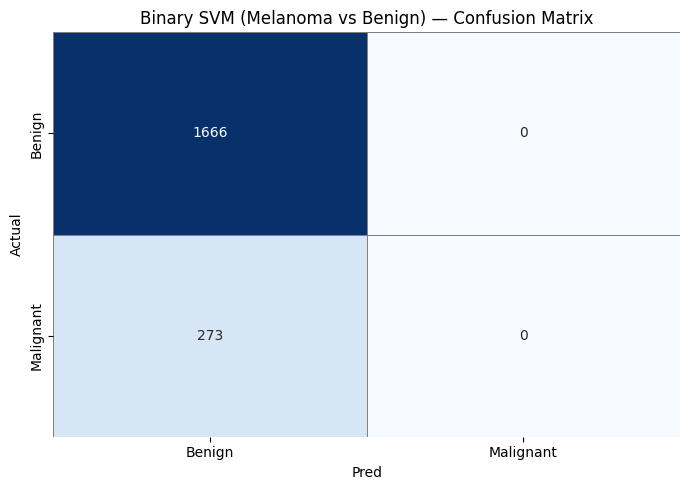

In [22]:
svm_binary, y_pred_binary, acc_binary = train_evaluate_svm(
    X_train_b, y_train_b, X_test_b, y_test_b,
    target_names=['Benign', 'Malignant'],
    title_prefix="Binary SVM (Melanoma vs Benign)",
)

#### Multi-class Classification (phân loại 7 loại bệnh da liễu)

In [23]:
list(le_dx.classes_)

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


Multi-class SVM (7 dx) — Accuracy: 0.7736
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        63
         bcc       0.00      0.00      0.00        65
         bkl       0.44      0.17      0.25       170
          df       0.00      0.00      0.00        18
         mel       0.60      0.05      0.09       117
          nv       0.79      0.99      0.88      1478
        vasc       0.00      0.00      0.00        28

    accuracy                           0.77      1939
   macro avg       0.26      0.17      0.17      1939
weighted avg       0.67      0.77      0.70      1939



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


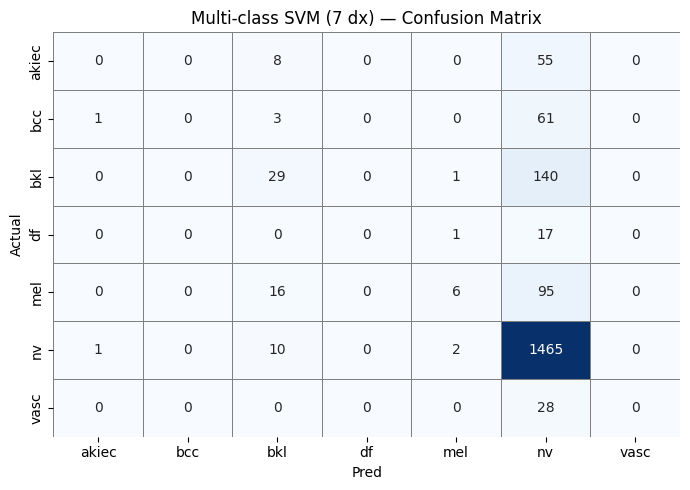

In [24]:
multi_target_names = list(le_dx.classes_)

svm_multi, y_pred_multi, acc_multi = train_evaluate_svm(
    X_train_m, y_train_m, X_test_m, y_test_m,
    target_names=multi_target_names,
    title_prefix="Multi-class SVM (7 dx)",
)

In [25]:
import math
# Function to test and display predictions for specific images
def test_and_display_images(model, scaler, image_paths, labels, number=5):
    # Extract features for the selected images
    features = extract_features(image_paths[:number])
    if len(features) == 0:
        print("No valid images to process.")
        return

    # Scale features
    features_scaled = scaler.transform(features)

    # Predict
    predictions = model.predict(features_scaled)
    label_map = {0: 'Benign', 1: 'Malignant'}

    # Display images with predictions
    # fig, axes = plt.subplots(1, number, figsize=(15, 5))
    # for idx, (path, pred, actual) in enumerate(zip(image_paths[:number], predictions, labels[:number])):
    #     img = mpimg.imread(path)
    #     ax = axes[idx] if number > 1 else axes
    #     ax.imshow(img, cmap='gray')
    #     ax.axis('off')
    #     ax.set_title(f"Pred: {label_map[pred]}\nActual: {label_map[actual]}")
    # Tính toán số hàng và số cột
    cols = 10
    rows = math.ceil(number / cols)
    # Thiết lập kích thước figure dựa trên số hàng
    fig, axes = plt.subplots(rows, cols, figsize=(20, 2 * rows))

    # Làm phẳng mảng axes để dễ duyệt qua (trường hợp chỉ có 1 hàng hoặc 1 ảnh)
    axes = axes.flatten() if number > 1 else [axes]
    for idx in range(cols * rows):
        ax = axes[idx]
        if idx < number:
            img = mpimg.imread(image_paths[idx])
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Pred: {label_map[predictions[idx]]}\nActual: {label_map[labels[idx]]}", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

Displaying predictions for 15 test images:


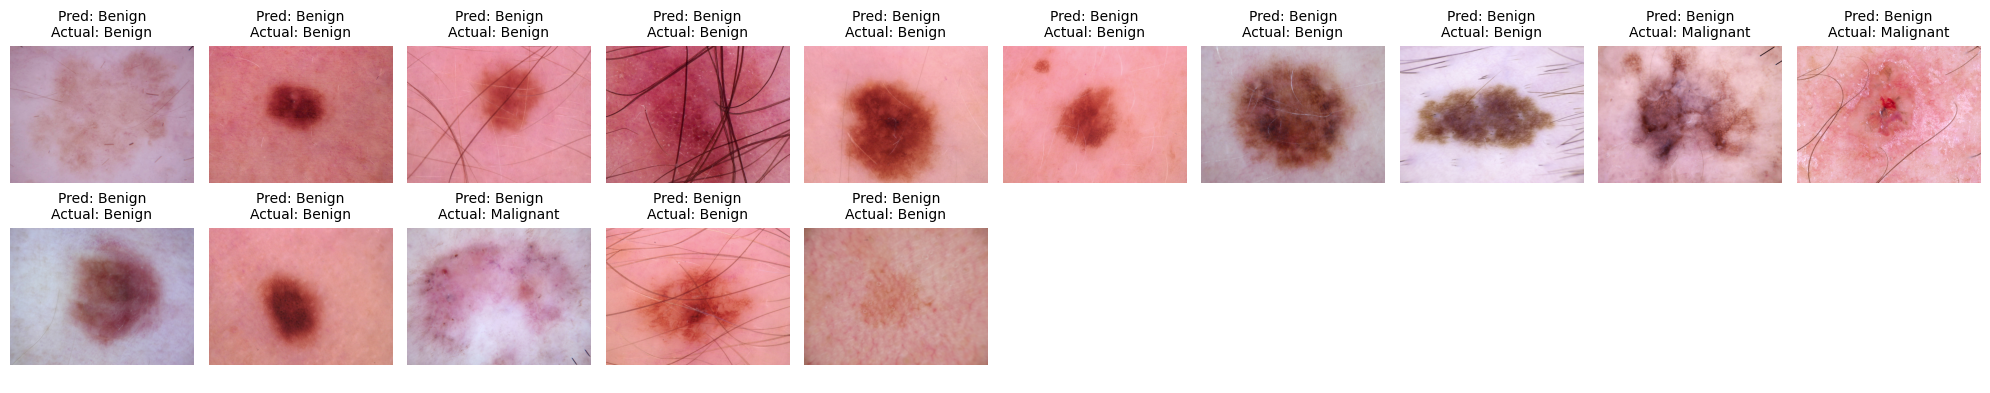

In [26]:
# Test and display predictions for n test images
n = 15
print(f"Displaying predictions for {n} test images:")
test_and_display_images(svm_binary, scaler, df_test['image_path'], df_test['binary_label'], number=n)

In [27]:
df_test

,image_id,image_path,lesion_id,dx_type,age,sex,localization,dx,diagnosis,binary_label,binary_name,sex_enc,localization_enc
0,ISIC_0031594,./image/ISIC_0031594.jpg,HAM_0006835,histo,75.0,male,chest,nv,melanocytic nevi,0,Benign (M),1,3
1,ISIC_0026269,./image/ISIC_0026269.jpg,HAM_0007205,follow_up,60.0,male,lower extremity,nv,melanocytic nevi,0,Benign (M),1,9
2,ISIC_0032130,./image/ISIC_0032130.jpg,HAM_0004072,follow_up,60.0,male,upper extremity,nv,melanocytic nevi,0,Benign (M),1,14
3,ISIC_0027212,./image/ISIC_0027212.jpg,HAM_0003341,follow_up,55.0,male,lower extremity,nv,melanocytic nevi,0,Benign (M),1,9
4,ISIC_0024392,./image/ISIC_0024392.jpg,HAM_0006311,follow_up,65.0,female,lower extremity,nv,melanocytic nevi,0,Benign (M),0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1934,ISIC_0026645,./image/ISIC_0026645.jpg,HAM_0003136,histo,65.0,male,back,akiec,actinic keratoses,1,Malignant (B),1,2
1935,ISIC_0025485,./image/ISIC_0025485.jpg,HAM_0005260,histo,65.0,male,scalp,bkl,benign keratosis,0,Benign (M),1,11
1936,ISIC_0033931,./image/ISIC_0033931.jpg,HAM_0005490,histo,70.0,male,upper extremity,mel,melanoma,1,Malignant (B),1,14
1937,ISIC_0024659,./image/ISIC_0024659.jpg,HAM_0001514,follow_up,60.0,male,trunk,nv,melanocytic nevi,0,Benign (M),1,12


## EDA nhanh (tùy chọn cho báo cáo)

In [36]:
# FIGURES_DIR = "/content/drive/MyDrive/Master/ML04/ML_DL_models/buoi_10/"

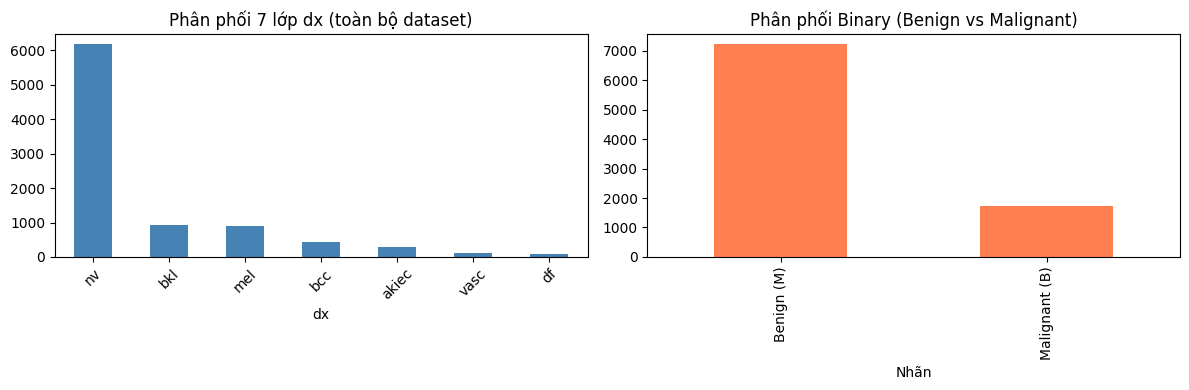

In [40]:
# Gộp train và test để EDA tổng quát
df_all = pd.concat([df_train, df_test], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_all["dx"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Phân phối 7 lớp dx (toàn bộ dataset)")
axes[0].set_xlabel("dx")
axes[0].tick_params(axis="x", rotation=45)

df_all["binary_name"].value_counts().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Phân phối Binary (Benign vs Malignant)")
axes[1].set_xlabel("Nhãn")

plt.tight_layout()
# plt.savefig(FIGURES_DIR + "eda_label_distribution.png", dpi=120)
plt.show()

/tmp/ipykernel_2523/2267562227.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x="binary_name", y="age", palette="Set2")


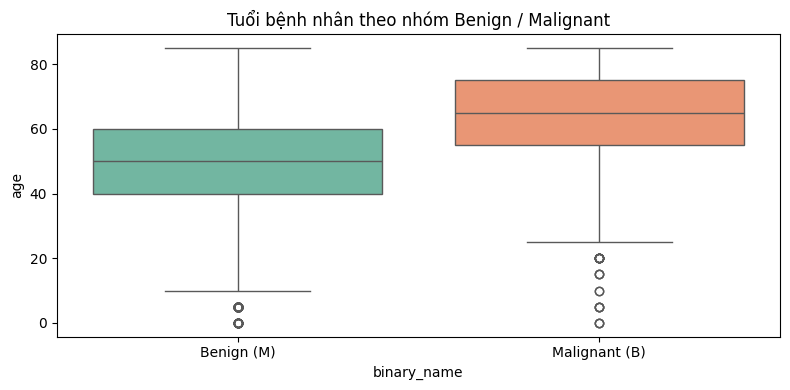

In [31]:
# Phân phối tuổi theo nhóm binary
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_all, x="binary_name", y="age", palette="Set2")
plt.title("Tuổi bệnh nhân theo nhóm Benign / Malignant")
plt.tight_layout()
# plt.savefig(FIGURES_DIR / "eda_age_by_binary.png", dpi=120)
plt.show()

### Tổng kết kết quả

In [32]:
summary = pd.DataFrame({
    "Bài toán": ["Binary (Melanoma vs Benign)", "Multi-class (7 dx)"],
    "Mô hình": ["SVM (linear)", "SVM (linear)"],
    "Accuracy": [acc_binary, acc_multi],
    "Mẫu train": [len(df_train), len(df_train)],
    "Mẫu test": [len(df_test), len(df_test)],
    "Số đặc trưng": [X_train_scaled.shape[1], X_train_scaled.shape[1]],
})
print(summary.to_string(index=False))

print("\nLưu ý khi viết báo cáo:")
print("- Nguồn dữ liệu: HuggingFace (ShiroOnigami23/skin-cancer-ham10000-dataset)")
print("- Dataset đã được chia train/test sẵn")
print("- Pipeline: Imputer → LabelEncoder (metadata) → trích xuất đặc trưng ảnh → StandardScaler → SVM")
print("- Các hình confusion matrix / EDA được lưu trong thư mục ./figures/")

                   Bài toán      Mô hình  Accuracy  Mẫu train  Mẫu test  Số đặc trưng
Binary (Melanoma vs Benign) SVM (linear)  0.859206       7009      1939          1766
         Multi-class (7 dx) SVM (linear)  0.773595       7009      1939          1766

Lưu ý khi viết báo cáo:
- Nguồn dữ liệu: HuggingFace (ShiroOnigami23/skin-cancer-ham10000-dataset)
- Dataset đã được chia train/test sẵn
- Pipeline: Imputer → LabelEncoder (metadata) → trích xuất đặc trưng ảnh → StandardScaler → SVM
- Các hình confusion matrix / EDA được lưu trong thư mục ./figures/


In [33]:
# Lưu mô hình & preprocessor (tùy chọn — dùng cho demo / tái sử dụng)
import joblib

IMG_FEATURE_NAMES = []
for ch, name in enumerate(["R", "G", "B"]):
    IMG_FEATURE_NAMES += [f"{name}_mean", f"{name}_std"]
    IMG_FEATURE_NAMES += [f"{name}_hist_{i}" for i in range(8)]
meta_cols = ["age", "sex_enc", "localization_enc"]
feature_names = meta_cols + IMG_FEATURE_NAMES
artifacts = {
    "svm_binary": svm_binary,
    "svm_multi": svm_multi,
    "scaler": scaler,
    # "imputer": imputer,
    "le_sex": le_sex,
    "le_loc": le_loc,
    "le_dx": le_dx,
    "dx_dict": dx_dict,
    "feature_names": feature_names,
    "dataset_source": "HuggingFace: ShiroOnigami23/skin-cancer-ham10000-dataset",
}
joblib.dump(artifacts, "/content/drive/MyDrive/Master/ML04/ML_DL_models/ham10000_svm_artifacts.joblib")
print("Đã lưu: ham10000_svm_artifacts.joblib")

Đã lưu: ham10000_svm_artifacts.joblib
